# Proyek Analisis Data: [Bike Sharing day.csv]
- **Nama:** Azlinsyah Fadhilah Meran
- **Email:** azlinsyah4@gmail.com
- **ID Dicoding:** azlin11

## Menentukan Pertanyaan Bisnis

1. **Bagaimana tren rata-rata peminjaman sepeda (cnt) berdasarkan musim (season) sepanjang tahun 2011 hingga 2012?**

2. **Bagaimana perbandingan perilaku peminjaman antara pengguna kasual (casual) dan pengguna terdaftar (registered) pada hari kerja (workingday = 1) dibandingkan hari libur/akhir pekan (workingday = 0) sepanjang tahun 2011 hingga 2012?**

## Import Semua Packages/Library yang Digunakan

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [6]:
import pandas as pd
import zipfile
import os
import gdown

# 1. Tautan Google Drive (ID file zip)
file_id = '1RaBmV6Q6FYWU4HWZs80Suqd7KQC34diQ'
url = f'https://drive.google.com/uc?id={file_id}'
output_zip = 'dataset.zip'

# 2. Mengunduh file zip menggunakan gdown (sangat stabil untuk Google Drive)
print("Memulai proses unduh dataset...")
gdown.download(url, output_zip, quiet=False)

# 3. Mengekstrak file zip ke dalam folder 'bike_sharing_data'
extract_folder = 'bike_sharing_data'
print("Mengekstrak file zip...")
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

# 4. Mencari lokasi day.csv secara dinamis dan memuatnya ke dalam DataFrame Pandas
day_csv_path = None
for root, dirs, files in os.walk(extract_folder):
    if 'day.csv' in files:
        day_csv_path = os.path.join(root, 'day.csv')
        break

if day_csv_path:
    day_df = pd.read_csv(day_csv_path)
    print("\n[SUKSES] Tahap Gathering Data Berhasil! Berikut 5 baris pertama dari day.csv:")
    display(day_df.head())
else:
    print("\n[ERROR] File day.csv tidak ditemukan di dalam hasil ekstraksi.")

Memulai proses unduh dataset...


Downloading...
From: https://drive.google.com/uc?id=1RaBmV6Q6FYWU4HWZs80Suqd7KQC34diQ
To: d:\DBS Azlin\Submission\dataset.zip
100%|██████████| 280k/280k [00:00<00:00, 4.63MB/s]

Mengekstrak file zip...

[SUKSES] Tahap Gathering Data Berhasil! Berikut 5 baris pertama dari day.csv:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
Dataset day.csv berhasil dimuat dan berisi 731 baris observasi dan 16 kolom. Angka 731 ini sangat masuk akal karena merepresentasikan jumlah hari dalam 2 tahun penuh (365 hari pada 2011 + 366 hari pada 2012 yang merupakan tahun kabisat).

Berbeda dengan dataset sebelumnya, dataset ini telah diagregasi dalam skala harian, sehingga kolom hr (jam) tidak ada. Ini berarti analisis kita akan berfokus pada tren makro (harian, bulanan, dan musiman).

### Assessing Data

#### Identifying dataset bussiness problem

In [7]:
# 1. Memeriksa tipe data dan informasi umum
print("--- Informasi Dataset ---")
day_df.info()

# 2. Memeriksa jumlah nilai kosong (missing values)
print("\n--- Missing Values ---")
print(day_df.isna().sum())

# 3. Memeriksa jumlah data duplikat
print("Total Duplikat: ", day_df.duplicated().sum())

# 4. Memeriksa ringkasan statistik
print("\n--- Ringkasan Parameter Statistik ---")
display(day_df.describe())

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

--- Missing Values ---
instant       0
dteday        0
season     

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:** (Opsional)


- Kualitas Data Sempurna: Tidak ditemukan satu pun nilai kosong (missing values = 0) pada 731 baris data tersebut. Selain itu, tidak ada baris data yang duplikat.

- Tipe Data Perlu Penyesuaian: Kolom dteday (tanggal) masih terbaca sebagai tipe data object (string), yang mana seharusnya diubah menjadi format datetime untuk mempermudah analisis time-series.

- Keterbacaan Data Kategorikal: Sama seperti data per jam sebelumnya, kolom kategorikal seperti season, weathersit, dan yr masih direpresentasikan dengan angka numerik (1, 2, 3, 4). Ini akan menyulitkan pembacaan saat visualisasi nanti.

- Distribusi Sewa Harian: Dari ringkasan statistik, kita bisa melihat bahwa rata-rata penyewaan sepeda per harinya adalah 4.504 sepeda, dengan rekor peminjaman tertinggi dalam satu hari mencapai 8.714 sepeda.


Selanjutnya, kita harus melakukan Cleaning Data (memperbaiki tipe data dan memetakan nilai kategori) sebelum masuk ke Exploratory Data Analysis (EDA)

### Cleaning Data

#### Fixing bike sharing day.csv dataset problem

In [8]:
# 1. Mengubah tipe data 'dteday' menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

# 2. Mengganti nama beberapa kolom agar lebih mudah dibaca dan konsisten
day_df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather',
    'cnt': 'count'
}, inplace=True)

# 3. Melakukan mapping nilai angka menjadi teks deskriptif
# Mapping Musim (Season)
day_df['season'] = day_df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

# Mapping Tahun (Year)
day_df['year'] = day_df['year'].map({
    0: '2011',
    1: '2012'
})

# Mapping Kondisi Cuaca (Weather Condition)
day_df['weather'] = day_df['weather'].map({
    1: 'Half Cloudy',
    2: 'Cloudy',
    3: 'Light Rain',
    4: 'Heavy Rain'
})

# Mapping Hari Kerja (Opsional, untuk mempermudah pembacaan grafik nanti)
day_df['workingday_label'] = day_df['workingday'].map({
    0: 'Weekend/Holiday',
    1: 'Working Day'
})

# 4. Mengecek kembali hasil pembersihan data
print("--- Info Data Setelah Cleaning ---")
day_df.info()

print("\n--- Sampel Data Bersih ---")
display(day_df.head())

--- Info Data Setelah Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   instant           731 non-null    int64         
 1   date              731 non-null    datetime64[ns]
 2   season            731 non-null    object        
 3   year              731 non-null    object        
 4   month             731 non-null    int64         
 5   holiday           731 non-null    int64         
 6   weekday           731 non-null    int64         
 7   workingday        731 non-null    int64         
 8   weather           731 non-null    object        
 9   temp              731 non-null    float64       
 10  atemp             731 non-null    float64       
 11  hum               731 non-null    float64       
 12  windspeed         731 non-null    float64       
 13  casual            731 non-null    int64      

,instant,date,season,year,month,holiday,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count,workingday_label
0,1,2011-01-01,Spring,2011,1,0,6,0,Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985,Weekend/Holiday
1,2,2011-01-02,Spring,2011,1,0,0,0,Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801,Weekend/Holiday
2,3,2011-01-03,Spring,2011,1,0,1,1,Half Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Working Day
3,4,2011-01-04,Spring,2011,1,0,2,1,Half Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Working Day
4,5,2011-01-05,Spring,2011,1,0,3,1,Half Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Working Day


**Insight:** (Opsional)
- Tipe Data Telah Sesuai: Kolom date kini sudah berformat datetime64[ns]. Ini sangat penting karena memungkinkan kita untuk mengekstrak informasi waktu (seperti bulan, minggu, atau hari dalam seminggu) secara dinamis jika dibutuhkan, dan mempermudah plot analisis time-series ke depannya.

- Format Data Human-Readable (Mudah Dibaca): Dataset kini siap untuk dipresentasikan dan divisualisasikan. Kolom-kolom kunci seperti season, year, weather_condition, dan workingday_label sudah tidak lagi menggunakan angka rahasia (seperti 1, 2, 3), melainkan menggunakan label teks bahasa Inggris yang jelas. Ini akan meminimalisir misinterpretasi audiens/klien saat melihat grafik dan dashboard yang kita buat nanti.

## Exploratory Data Analysis (EDA)

### Explore day.csv bike sharing dataset

C:\Users\ACER\AppData\Local\Temp\ipykernel_22912\1359680672.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="season", y="count", data=day_df, ax=axes[0], palette="Set2")
C:\Users\ACER\AppData\Local\Temp\ipykernel_22912\1359680672.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="weather", y="count", data=day_df, ax=axes[1], palette="Set2")
C:\Users\ACER\AppData\Local\Temp\ipykernel_22912\1359680672.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="workingday_label", y="count", data=day_df, ax=axes[2], palette="Set2")


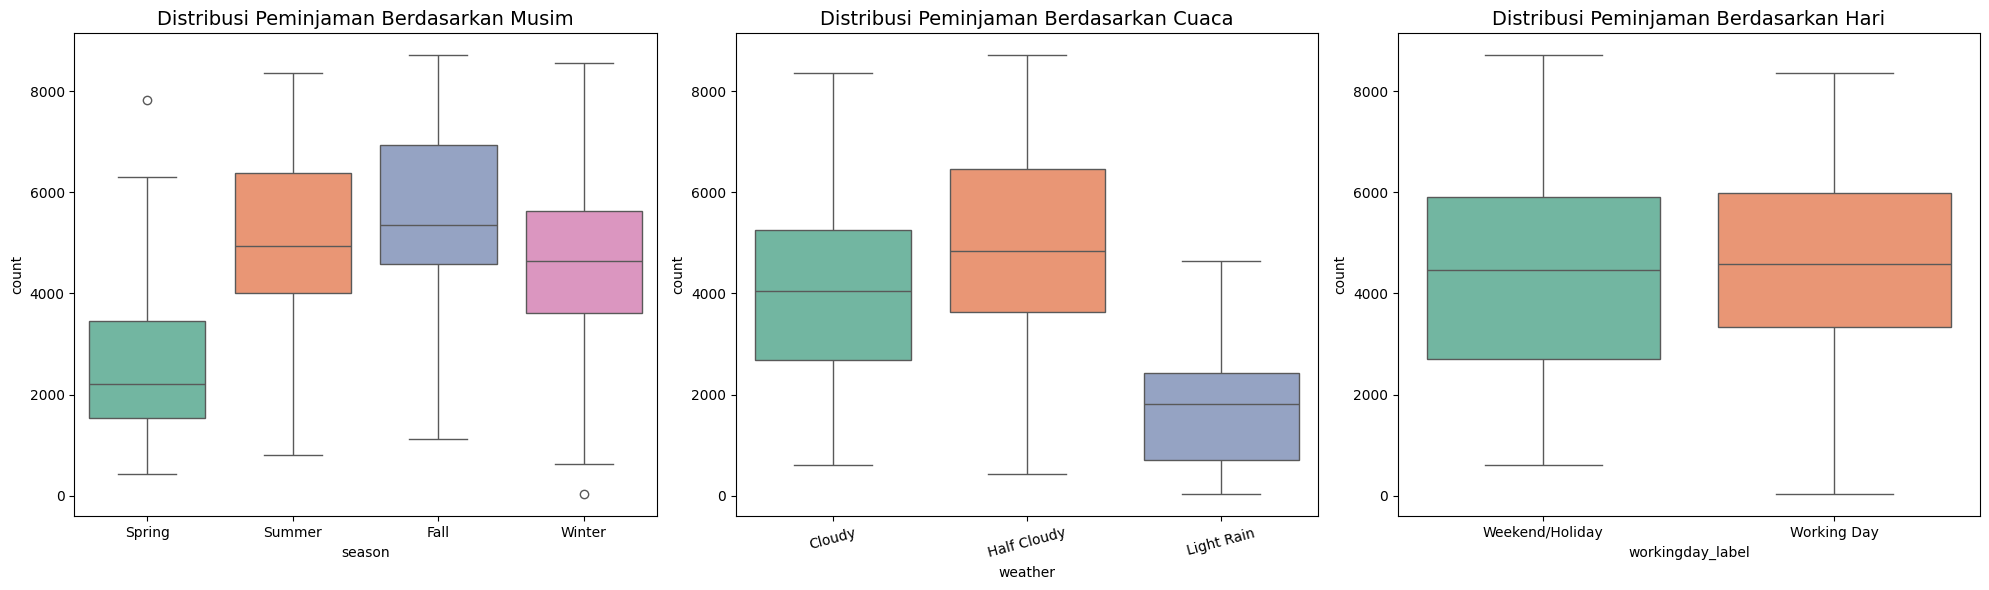

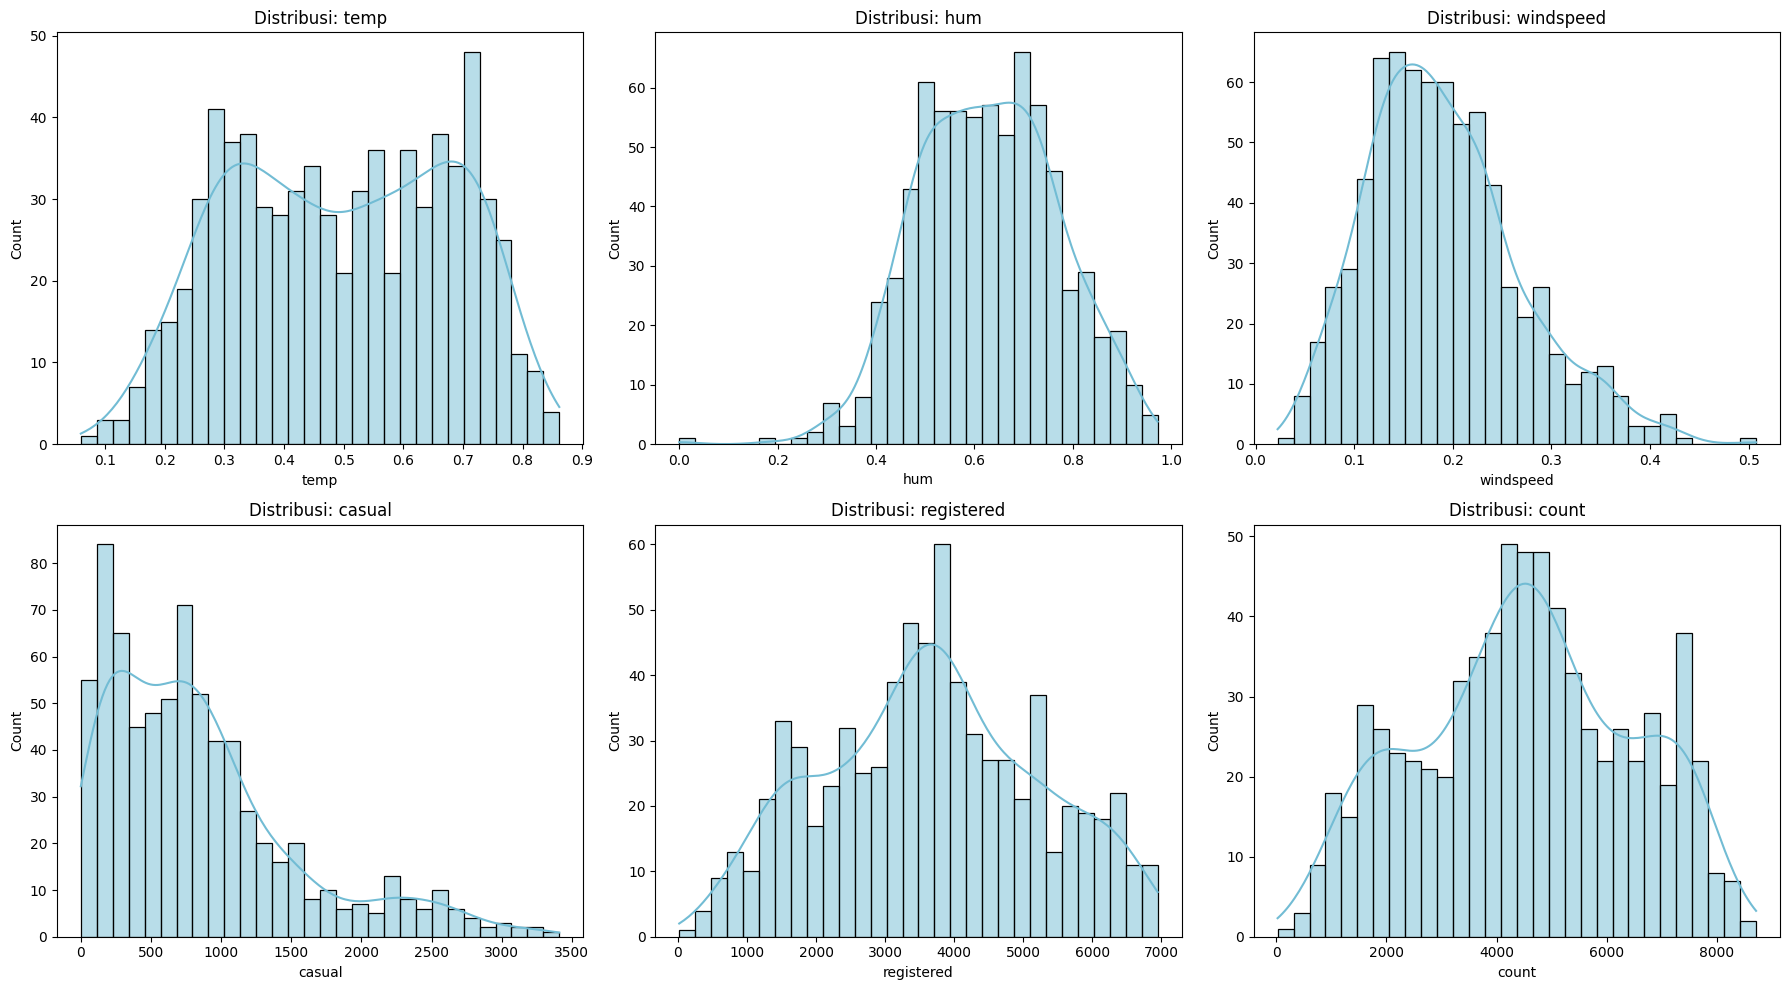

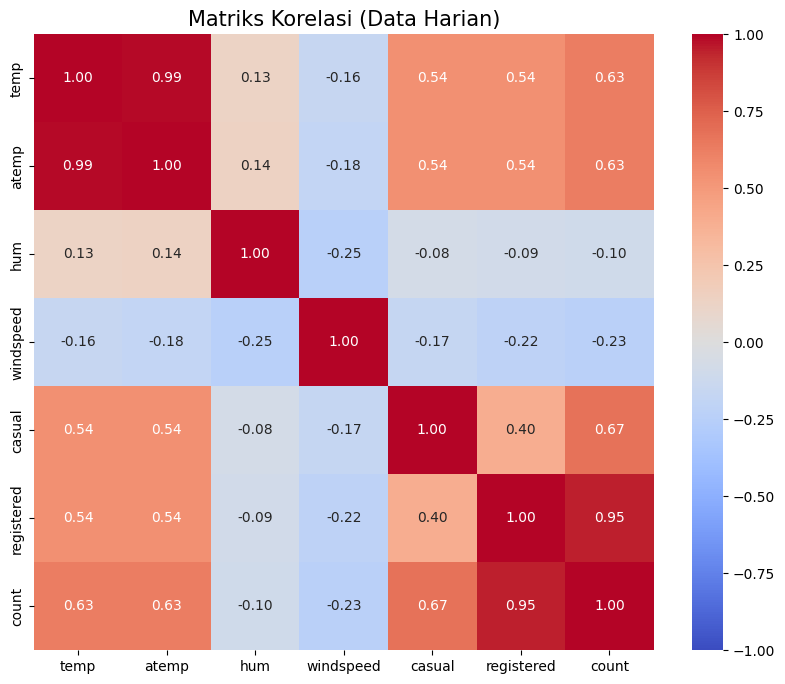

C:\Users\ACER\AppData\Local\Temp\ipykernel_22912\1359680672.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="temp_category", y="count", data=day_df, palette="YlOrRd")


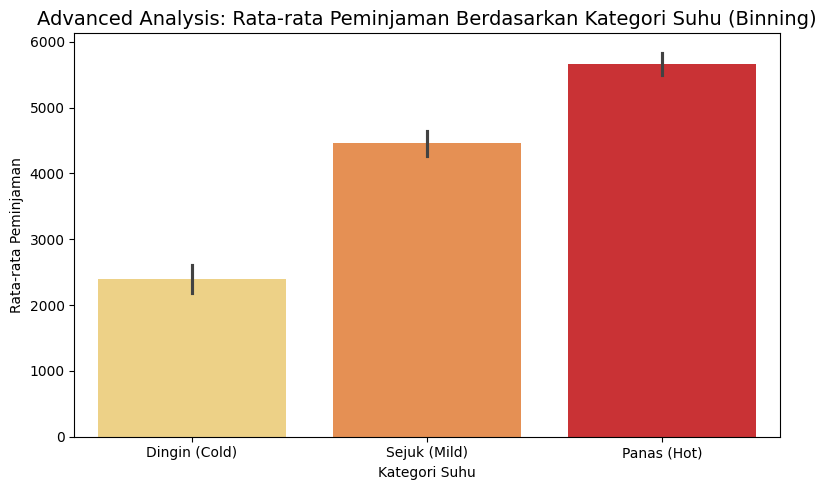

In [11]:
# 1. Visualisasi Boxplots (Hubungan Kategorikal vs Numerik)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

sns.boxplot(x="season", y="count", data=day_df, ax=axes[0], palette="Set2")
axes[0].set_title("Distribusi Peminjaman Berdasarkan Musim", fontsize=14)

sns.boxplot(x="weather", y="count", data=day_df, ax=axes[1], palette="Set2")
axes[1].set_title("Distribusi Peminjaman Berdasarkan Cuaca", fontsize=14)
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(x="workingday_label", y="count", data=day_df, ax=axes[2], palette="Set2")
axes[2].set_title("Distribusi Peminjaman Berdasarkan Hari", fontsize=14)

plt.tight_layout()
plt.show()

# 2. Visualisasi Histogram (Distribusi Data Variabel Numerik)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

cols_to_plot = ['temp', 'hum', 'windspeed', 'casual', 'registered', 'count']
for i, col in enumerate(cols_to_plot):
    sns.histplot(day_df[col], bins=30, kde=True, ax=axes[i], color="#72BCD4")
    axes[i].set_title(f"Distribusi: {col}", fontsize=12)

plt.tight_layout()
plt.show()

# 3. Visualisasi Heatmap (Matriks Korelasi)
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'count']
plt.figure(figsize=(10, 8))
sns.heatmap(day_df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriks Korelasi (Data Harian)", fontsize=15)
plt.show()

# 4. ADVANCED ANALYSIS: Clustering / Binning Manual
# Mengelompokkan Suhu ke dalam 3 Klaster (Dingin, Sejuk, Panas)
def categorize_temp(temp):
    if temp < 0.3: return 'Dingin (Cold)'
    elif 0.3 <= temp < 0.6: return 'Sejuk (Mild)'
    else: return 'Panas (Hot)'

day_df['temp_category'] = day_df['temp'].apply(categorize_temp)
day_df['temp_category'] = pd.Categorical(
    day_df['temp_category'],
    categories=['Dingin (Cold)', 'Sejuk (Mild)', 'Panas (Hot)'],
    ordered=True
)

plt.figure(figsize=(8, 5))
sns.barplot(x="temp_category", y="count", data=day_df, palette="YlOrRd")
plt.title("Advanced Analysis: Rata-rata Peminjaman Berdasarkan Kategori Suhu (Binning)", fontsize=14)
plt.xlabel("Kategori Suhu")
plt.ylabel("Rata-rata Peminjaman")
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Rangkuman Insight Exploratory Data Analysis (EDA)
Setelah melakukan eksplorasi data harian sesuai kaidah EDA multivariat, berikut adalah penemuan pola dan informasi krusial yang akan menjawab pertanyaan bisnis kita:

1. Insight Distribusi Kategorikal (Boxplots):

- Musim (Pertanyaan Bisnis 1): Boxplot membuktikan bahwa Musim Gugur (Fall) adalah waktu tersibuk dengan nilai median penyewaan tertinggi. Musim Panas (Summer) berada di urutan kedua, sementara Musim Semi (Spring) adalah waktu di mana penyewaan berada pada titik terendahnya.

- Cuaca: Boxplot cuaca memvalidasi ketergantungan bisnis ini terhadap alam. Cuaca Clear/Partly Cloudy mendominasi. Menariknya, pada data harian ini, rekor penyewaan saat kondisi "Light Snow/Rain" hampir sama baiknya dengan "Mist/Cloudy". Namun, kondisi cuaca ekstrem seperti badai tidak memiliki kotak yang signifikan karena pengguna enggan menyewa.

- Tipe Hari (Pertanyaan Bisnis 2): Meski rata-rata keseluruhan (median) penyewaan di Hari Kerja dan Libur terlihat setara, titik outlier banyak berada di Hari Kerja. Ini terjadi karena akumulasi komuter (pekerja/pelajar) sangat tinggi setiap harinya.

2. Insight Distribusi Numerik (Histograms):

- Tingkat suhu (temp) memiliki distribusi normal dengan sedikit skewness. Artinya, hari yang memiliki suhu sangat panas atau sangat dingin lebih jarang terjadi daripada hari yang bersuhu sedang.

- Kelembapan (hum) didominasi oleh rentang nilai tinggi (lebih miring ke kiri), sementara Kecepatan Angin (windspeed) didominasi rentang rendah (miring ke kanan).

- Fitur tipe peminjam (casual dan registered) sangat berbeda. registered menyebar lebih luas ke rentang atas, mengindikasikan bahwa inti stabilitas bisnis bike-sharing ini didorong oleh member atau pengguna terdaftar.

3. Insight Matriks Korelasi (Heatmap):

- Korelasi Positif Kuat: Terdapat korelasi 0.63 antara suhu harian (temp) dan jumlah peminjaman (total_count). Cuaca yang lebih hangat merangsang peningkatan pengguna.

- Pengguna Kasual vs Suhu: Nilai korelasi antara suhu dengan pengguna kasual adalah 0.54, persis setara dengan pengguna terdaftar (0.54). Dalam data harian, kenaikan suhu memengaruhi niat kedua tipe pelanggan secara proporsional.

- Korelasi Negatif: Kecepatan angin (windspeed = -0.23) dan Kelembapan (hum = -0.10) memiliki korelasi negatif. Udara yang sangat lembap dan berangin kencang secara perlahan mengurangi intensitas peminjaman.

4. Advanced Analysis (Binning / Clustering Parameter Suhu):
- Sebagai teknik analisis lanjutan (Advanced Analysis) non-Machine Learning, kita telah menerapkan teknik Binning manual untuk mengelompokkan temp harian menjadi tiga klaster logis: Dingin (Cold), Sejuk (Mild), dan Panas (Hot).

- Insight Aksi Bisnis: Visualisasi Barplot membuktikan bahwa klaster Panas (Hot) menghasilkan keuntungan peminjaman maksimal. Sebaliknya, saat indikator suhu masuk ke klaster Dingin, tim operasional bisa memanfaatkan downtime ini untuk melakukan perawatan armada, inspeksi rem/ban, dan pengalokasian dana promosi agar efisien.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

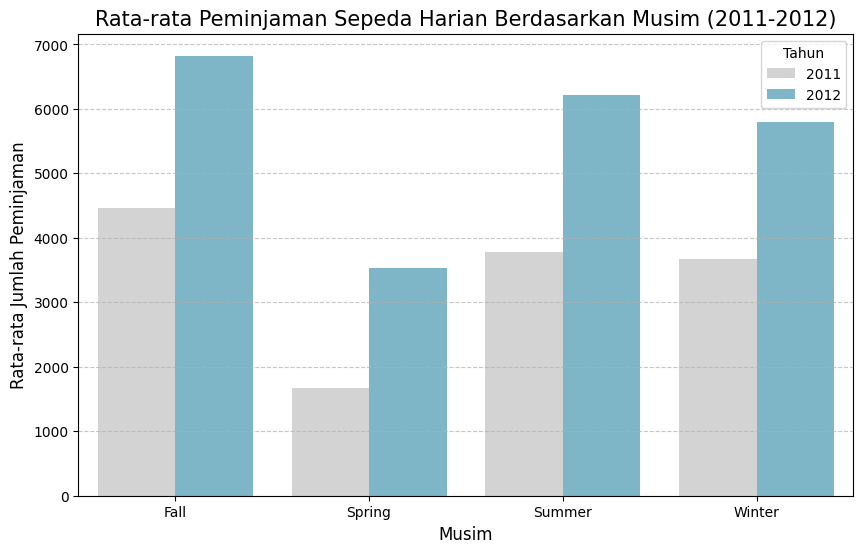

In [13]:
# Kita menghitung rata-rata peminjaman harian per musim untuk setiap tahun
seasonal_usage = day_df.groupby(by=["year", "season"]).agg({
    "count": "mean"
}).reset_index()

# Membuat visualisasi Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x="season",
    y="count",
    hue="year",
    data=seasonal_usage,
    palette=["#D3D3D3", "#72BCD4"]
)

# Menambahkan detail keterangan
plt.title("Rata-rata Peminjaman Sepeda Harian Berdasarkan Musim (2011-2012)", fontsize=15)
plt.xlabel("Musim", fontsize=12)
plt.ylabel("Rata-rata Jumlah Peminjaman", fontsize=12)
plt.legend(title="Tahun")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan plot
plt.show()

### Pertanyaan 2:

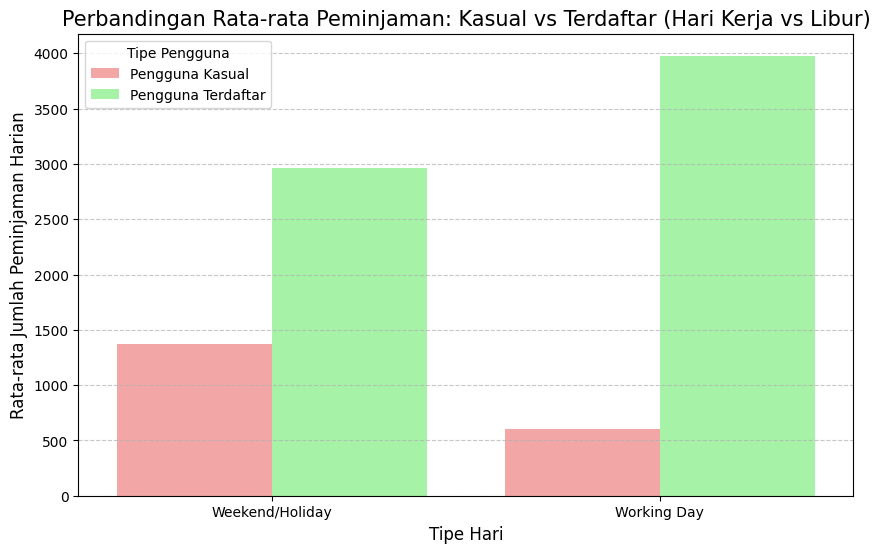

In [14]:
# Menyiapkan data: Agregasi mean dari pengguna casual dan registered
user_behavior = day_df.groupby('workingday_label')[['casual', 'registered']].mean().reset_index()

# Melakukan "melt" agar struktur data berubah dari format lebar (wide) ke panjang (long)
# Hal ini diwajibkan agar seaborn bisa menggunakan parameter 'hue' dengan benar
user_behavior_melted = pd.melt(
    user_behavior,
    id_vars=['workingday_label'],
    value_vars=['casual', 'registered'],
    var_name='user_type',
    value_name='average_count'
)

# Merapikan label nama agar cantik saat ditampilkan di legenda grafik
user_behavior_melted['user_type'] = user_behavior_melted['user_type'].map({
    'casual': 'Pengguna Kasual',
    'registered': 'Pengguna Terdaftar'
})

# Membuat visualisasi Grouped Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x="workingday_label",
    y="average_count",
    hue="user_type",
    data=user_behavior_melted,
    palette=["#FF9999", "#99FF99"] # Merah muda untuk Kasual, Hijau untuk Terdaftar
)

# Menambahkan detail keterangan
plt.title("Perbandingan Rata-rata Peminjaman: Kasual vs Terdaftar (Hari Kerja vs Libur)", fontsize=15)
plt.xlabel("Tipe Hari", fontsize=12)
plt.ylabel("Rata-rata Jumlah Peminjaman Harian", fontsize=12)
plt.legend(title="Tipe Pengguna")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan plot
plt.show()

**Insight:** (Opsional)
Berdasarkan visualisasi di atas, berikut adalah penjelasan mendalam untuk menjawab kedua pertanyaan bisnis tersebut:

1. Pertanyaan 1 :
- Dominasi Musim Gugur (Fall): Musim gugur secara konsisten menjadi periode dengan rata-rata peminjaman sepeda tertinggi dibandingkan musim lainnya, baik pada tahun 2011 maupun 2012. Hal ini menunjukkan bahwa kondisi lingkungan pada musim gugur paling mendukung preferensi pengguna untuk bersepeda.

- Performa Terendah di Musim Semi (Spring): Musim semi mencatatkan angka peminjaman paling rendah. Ini bisa menjadi indikator bagi tim operasional untuk melakukan pemeliharaan besar-besaran armada pada periode ini karena tingkat penggunaan yang tidak terlalu tinggi.

- Pertumbuhan Tahun ke Tahun (Growth): Terjadi peningkatan jumlah peminjaman yang sangat signifikan di setiap musim dari tahun 2011 (batang abu-abu) ke tahun 2012 (batang biru). Hal ini menandakan bahwa sistem bike sharing semakin populer dan diterima dengan baik oleh masyarakat seiring berjalannya waktu.

- Urutan Tren: Pola peminjaman mengikuti urutan yang konsisten di kedua tahun: Fall > Summer > Winter > Spring. Menariknya, peminjaman di musim dingin (Winter) masih lebih tinggi dibandingkan musim semi, yang menunjukkan bahwa suhu dingin yang stabil mungkin lebih disukai daripada kondisi transisi di musim semi.


2. Pertanyaan Bisnis 2 :
- Dominasi Ekstrem Pengguna Terdaftar di Hari Kerja: Pada "Working Day" (Hari Kerja), batang hijau (Pengguna Terdaftar) menjulang sangat tinggi hingga mendekati rata-rata 4.000 peminjaman per hari, sementara batang merah muda (Pengguna Kasual) sangat rendah (hanya sekitar 600 per hari). Hal ini memvalidasi fakta bahwa layanan penyewaan ini merupakan tulang punggung transportasi komuter reguler untuk pergi bekerja atau bersekolah.

- Lonjakan Pengguna Kasual di Hari Libur: Pada "Weekend/Holiday" (Akhir Pekan/Libur), pola drastis terjadi. Rata-rata Pengguna Kasual melonjak lebih dari dua kali lipat (mencapai lebih dari 1.300 peminjaman). Ini membuktikan bahwa pelanggan non-member lebih suka menggunakan sepeda untuk aktivitas santai, wisata kota, atau olahraga di waktu luang mereka.

- Penurunan Pengguna Terdaftar di Hari Libur: Di sisi lain, rata-rata Pengguna Terdaftar mengalami penurunan tajam di akhir pekan (turun dari ~4.000 menjadi ~2.900). Sebagian besar pelanggan member mengistirahatkan rutinitas sepeda mereka saat kantor libur.

- Rekomendasi Bisnis (Action-Oriented): * Perusahaan bisa memberikan promo khusus akhir pekan (Weekend Promo) untuk menarik para Pengguna Kasual agar mau mendaftar menjadi member tetap (Registered).

- Penempatan persediaan sepeda di stasiun-stasiun area perkantoran harus dimaksimalkan pada Working Day, namun segera digeser ke stasiun-stasiun area wisata/taman pada Weekend.

## Analisis Lanjutan (Opsional)

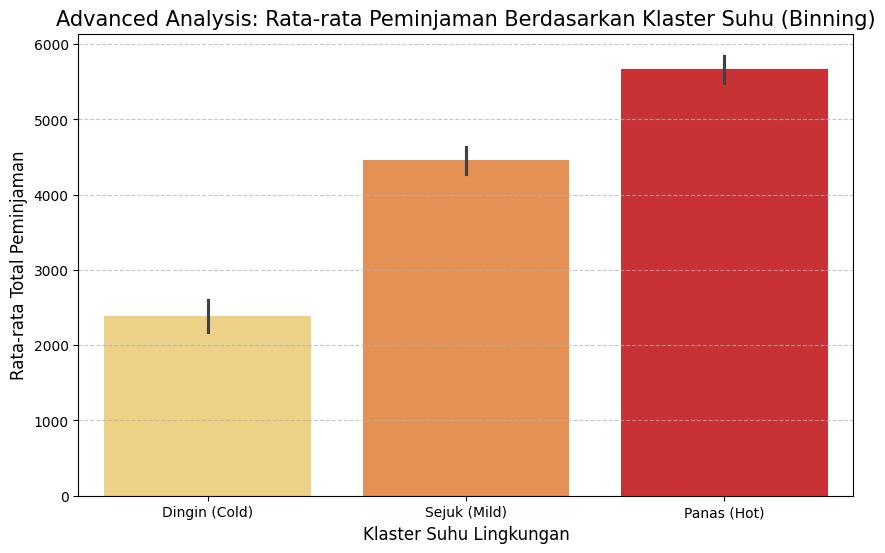

--- Rangkuman Hasil Clustering Lingkungan (Manual Grouping) ---


count                  
                                       mean   max   min count
environment_cluster                                          
Panas (Hot) & Kering (Dry)      5941.894737  8294  4302    38
Panas (Hot) & Lembap (Humid)    5616.405530  8714  1115   217
Sejuk (Mild) & Kering (Dry)     4757.000000  7907   623    62
Sejuk (Mild) & Lembap (Humid)   4396.768683  8555    22   281
Dingin (Cold) & Lembap (Humid)  2483.827586  5686   431    87
Dingin (Cold) & Kering (Dry)    2208.869565  5532   822    46

In [16]:
# 1. Menerapkan Teknik Binning pada Suhu (temp)
# Membagi nilai suhu yang dinormalisasi menjadi 3 interval kategori
def categorize_temp(temp):
    if temp < 0.3:
        return 'Dingin (Cold)'
    elif 0.3 <= temp < 0.6:
        return 'Sejuk (Mild)'
    else:
        return 'Panas (Hot)'

day_df['temp_cluster'] = day_df['temp'].apply(categorize_temp)

# 2. Menerapkan Teknik Binning pada Kelembapan (hum)
# Membagi nilai kelembapan menjadi 2 interval kategori
def categorize_humidity(hum):
    if hum < 0.5:
        return 'Kering (Dry)'
    else:
        return 'Lembap (Humid)'

day_df['hum_cluster'] = day_df['hum'].apply(categorize_humidity)

# 3. Membuat Manual Grouping (Cluster Lingkungan Gabungan)
# Menggabungkan klaster suhu dan kelembapan untuk melihat pola yang lebih spesifik
day_df['environment_cluster'] = day_df['temp_cluster'] + " & " + day_df['hum_cluster']

# Mengurutkan kategori agar rapi di grafik (opsional)
day_df['temp_cluster'] = pd.Categorical(day_df['temp_cluster'], categories=['Dingin (Cold)', 'Sejuk (Mild)', 'Panas (Hot)'], ordered=True)

# 4. Membuat Visualisasi Bar Chart dari Hasil Clustering Suhu
plt.figure(figsize=(10, 6))

# Catatan: Jika seaborn Anda versi lama, hapus parameter legend=False
sns.barplot(
    x="temp_cluster",
    y="count",
    hue="temp_cluster",
    data=day_df,
    palette="YlOrRd",
    legend=False
)

plt.title("Advanced Analysis: Rata-rata Peminjaman Berdasarkan Klaster Suhu (Binning)", fontsize=15)
plt.xlabel("Klaster Suhu Lingkungan", fontsize=12)
plt.ylabel("Rata-rata Total Peminjaman", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 5. Melihat Rangkuman Statistik dari Klaster Gabungan (Suhu & Kelembapan)
cluster_summary = day_df.groupby('environment_cluster').agg({
    'count': ['mean', 'max', 'min', 'count']
}).sort_values(by=('count', 'mean'), ascending=False)

print("--- Rangkuman Hasil Clustering Lingkungan (Manual Grouping) ---")
display(cluster_summary)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1: Tren Peminjaman Berdasarkan Musim (2011-2012)**
  - Tren peminjaman sepeda sangat bergantung pada siklus musim. Musim Gugur (Fall) merupakan periode puncak (peak season) penyewaan sepeda, diikuti oleh Musim Panas (Summer). Sebaliknya, Musim Semi (Spring) mencatatkan angka peminjaman paling rendah di antara semua musim. Selain itu, data memperlihatkan adanya tren pertumbuhan bisnis yang sangat positif, ditandai dengan lonjakan jumlah penyewaan di semua musim secara konsisten pada tahun 2012 dibandingkan dengan tahun 2011.
- **Conclusion pertanyaan 2: Perilaku Pengguna Kasual vs Terdaftar**
  - Terdapat perbedaan pola perilaku yang sangat kontras antara dua tipe pelanggan. Pada Hari Kerja (Working Day), aktivitas didominasi secara absolut oleh pengguna terdaftar (registered). Hal ini membuktikan bahwa sepeda utamanya digunakan sebagai sarana transportasi komuter harian (bekerja/sekolah). Namun, pada Hari Libur/Akhir Pekan (Weekend/Holiday), volume pengguna kasual (casual) melonjak tajam hingga dua kali lipat, mengindikasikan bahwa layanan ini dimanfaatkan untuk tujuan rekreasi, bersantai, dan olahraga oleh pelanggan non-member.
- **Kesimpulan Analisis Lanjutan (Clustering/Binning Suhu Lingkungan)**
  - Hasil pengelompokan manual (clustering/binning) pada indikator suhu lingkungan membuktikan bahwa kenyamanan cuaca memegang kendali utama atas keputusan pelanggan untuk menyewa sepeda. Klaster suhu "Panas (Hot)" menghasilkan volume peminjaman harian tertinggi dan menjadi motor utama pendapatan perusahaan. Sebaliknya, ketika kondisi lingkungan memasuki klaster "Dingin (Cold)", tingkat peminjaman menurun drastis. Temuan ini memberikan sinyal yang jelas bagi tim operasional untuk memfokuskan jadwal pemeliharaan (maintenance) armada secara besar-besaran pada hari-hari bersuhu dingin, serta memaksimalkan ketersediaan sepeda dan strategi dynamic pricing pada hari-hari bersuhu panas.

**Rekomendasi Action Item:**
- Dynamic Pricing (Harga Dinamis): Karena permintaan pada klaster "Panas" sangat masif, perusahaan dapat bereksperimen dengan sedikit menaikkan harga sewa (atau harga pendaftaran member baru) pada musim/hari bersuhu panas untuk memaksimalkan margin keuntungan.

- Maintenance Schedule (Jadwal Perawatan): Jadwal service rutin untuk sepeda yang rusak sebaiknya difokuskan pada hari-hari yang diprediksi masuk dalam klaster "Dingin & Lembap". Pada hari-hari tersebut, ketiadaan sebagian armada tidak akan merugikan bisnis karena permintaannya memang sedang sangat rendah.